In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import shap
import matplotlib.pyplot as plt

# ==========================================
# 1. GERAÇÃO DOS DADOS SINTÉTICOS (1.000 linhas)
# ==========================================
np.random.seed(42)
n_samples = 1000

# Criando as features de telemetria
dados = {
    'temperatura_sensor_C': np.random.normal(20, 15, n_samples),
    'nivel_radiacao_rads': np.random.exponential(5, n_samples),
    'latencia_ms': np.random.normal(150, 50, n_samples),
    'tensao_bateria_V': np.random.uniform(10.0, 14.4, n_samples),
    'taxa_erros_pacote': np.random.uniform(0.0, 0.2, n_samples),
    'vibracao_hz': np.random.normal(50, 10, n_samples),
    'desgaste_componente_perc': np.random.randint(0, 100, n_samples),
    'interferencia_magnetica': np.random.uniform(0, 10, n_samples),
    'carga_processamento_perc': np.random.uniform(10, 95, n_samples)
}

df = pd.DataFrame(dados)

# Regra de Negócio do SpaceData Triage:
# Definindo o que é um "Dado Inválido/Ruído" (0) e "Dado Útil" (1)
# Ex: Alta radiação, muitos erros de pacote ou falha de tensão corrompem o dado.
condicao_ruido = (
    (df['nivel_radiacao_rads'] > 15) | 
    (df['taxa_erros_pacote'] > 0.15) | 
    (df['tensao_bateria_V'] < 11.5)
)

# Se bater a condição de ruído, é 0 (Descartar). Senão, é 1 (Manter/Útil).
df['Dado_Valido'] = np.where(condicao_ruido, 0, 1)

print(f"Distribuição das Classes:\n{df['Dado_Valido'].value_counts(normalize=True) * 100}\n")

# ==========================================
# 2. PREPARAÇÃO E COMPARAÇÃO DE MODELOS
# ==========================================
X = df.drop('Dado_Valido', axis=1)
y = df['Dado_Valido']

# Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo 1: Random Forest (Geralmente lida melhor com regras não lineares)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Modelo 2: Regressão Logística (Mais simples e interpretável linearmente)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("--- DESEMPENHO DOS MODELOS ---")
print(f"Acurácia Random Forest: {rf_acc * 100:.2f}%")
print(f"Acurácia Regressão Logística: {lr_acc * 100:.2f}%\n")

C:\Users\guili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Distribuição das Classes:
Dado_Valido
0    52.4
1    47.6
Name: proportion, dtype: float64

--- DESEMPENHO DOS MODELOS ---
Acurácia Random Forest: 99.50%
Acurácia Regressão Logística: 76.50%



Gerando análise SHAP para o modelo Random Forest...


C:\Users\guili\AppData\Local\Temp\ipykernel_4340\3210880277.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_para_plotar, X_test, plot_type="dot")


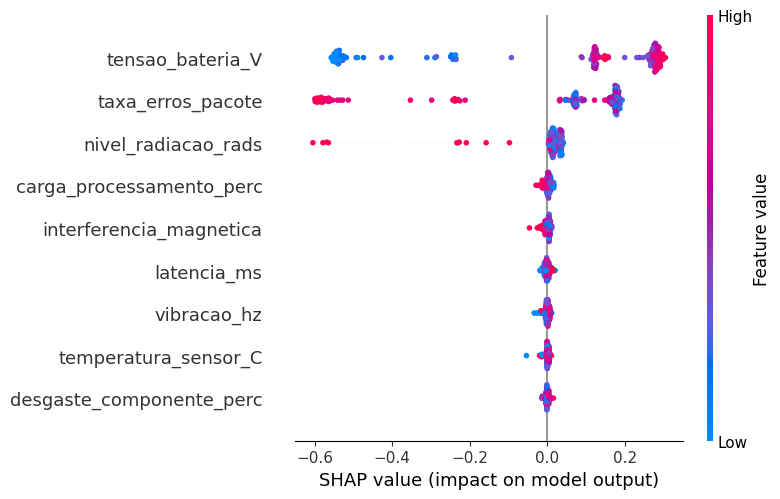

In [3]:
# ==========================================
# 3. INTERPRETABILIDADE DO MODELO COM SHAP (CORRIGIDO)
# ==========================================
print("Gerando análise SHAP para o modelo Random Forest...")

# Criar o explainer
explainer = shap.TreeExplainer(rf_model)

# Obter os valores numéricos brutos
shap_values_raw = explainer.shap_values(X_test)

# Verificação inteligente para lidar com qualquer versão da biblioteca SHAP
if isinstance(shap_values_raw, list):
    # Para versões antigas do SHAP
    valores_para_plotar = shap_values_raw[1]
elif len(shap_values_raw.shape) == 3:
    # Para versões novas do SHAP (amostras, features, classes)
    valores_para_plotar = shap_values_raw[:, :, 1]
else:
    # Caso a biblioteca já retorne a dimensão achatada
    valores_para_plotar = shap_values_raw

# Gerar o gráfico (tire um print dessa imagem para o README!)
shap.summary_plot(valores_para_plotar, X_test, plot_type="dot")